In [39]:
import kagglehub
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler

path = kagglehub.dataset_download("romaneyvazov/penguins-lter")
full_path = os.path.join(path, "penguins_size.csv")
dataset = pd.read_csv(full_path)

dataset = dataset.dropna()

y_labels = dataset['species']

X_data = dataset.drop('species', axis=1)
X_data = pd.get_dummies(X_data, columns=['island', 'sex'], drop_first=True)

scaler = StandardScaler()
cols_to_scale = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
X_data[cols_to_scale] = scaler.fit_transform(X_data[cols_to_scale])

--------------------3--------------------
Species  Adelie  Chinstrap  Gentoo
Cluster                           
0           0.0        0.0   100.0
1          60.0       40.0     0.0
2          77.8       22.2     0.0

Anomalies:
species
Chinstrap    10
Gentoo        5
Adelie        2
--------------------4--------------------
Species  Adelie  Chinstrap  Gentoo
Cluster                           
0          77.8       22.2     0.0
1           0.0        0.0   100.0
2           0.0        0.0   100.0
3          60.0       40.0     0.0

Anomalies:
species
Chinstrap    12
Adelie        4
Gentoo        1
--------------------5--------------------
Species  Adelie  Chinstrap  Gentoo
Cluster                           
0         100.0        0.0     0.0
1           0.0        0.0   100.0
2          92.3        7.7     0.0
3           0.0      100.0     0.0
4           0.0        0.0   100.0

Anomalies:
species
Chinstrap    10
Adelie        6
Gentoo        1
--------------------3-------------------

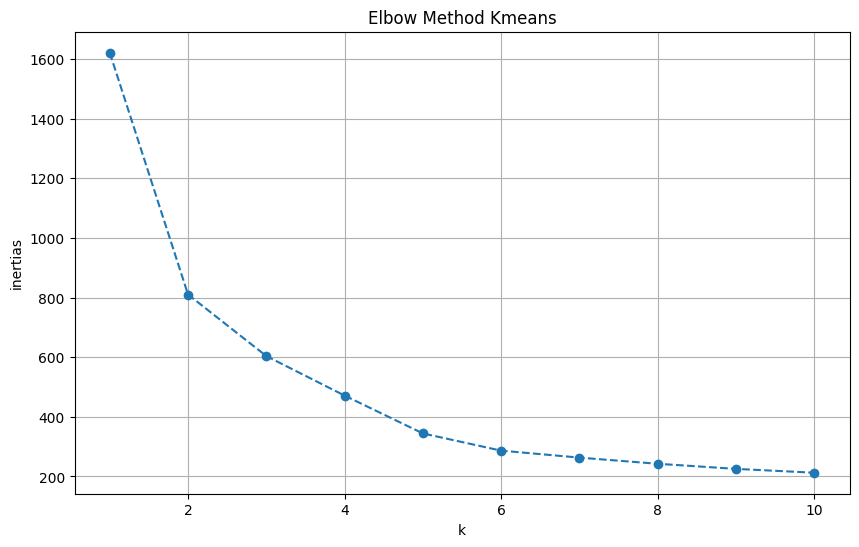

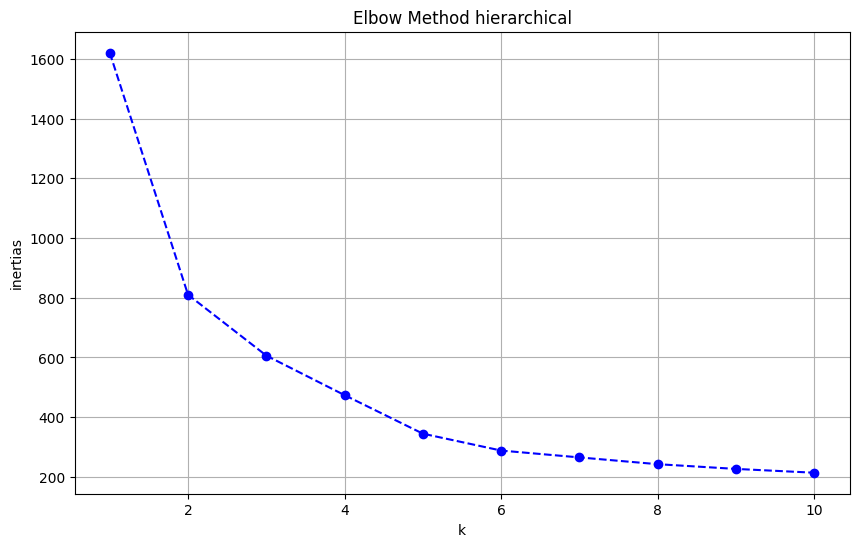

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances_argmin_min
import scipy.cluster.hierarchy as sch
import numpy as np

def analyze_cluster_composition(k_range, X_data, y_true):
    for k in k_range:
        print(20*"-" + f'{k}' + 20*"-")

        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = model.fit_predict(X_data)
        distances = model.transform(X_data)

        df = pd.DataFrame({'Cluster': labels, 'Species': y_true})
        
        composition = pd.crosstab(df['Cluster'], df['Species'], normalize='index') * 100
        
        print(composition.round(1))
        
        dist_to_center = distances.min(axis=1)
        threshold = np.percentile(dist_to_center, 95)
        
        anomalies_mask = dist_to_center > threshold
        
        anomalies_species = y_true[anomalies_mask]
        n_anomalies = len(anomalies_species)
        
        print(f"\nAnomalies:")
        
        if n_anomalies > 0:
            print(anomalies_species.value_counts().to_string())
            
            
def analyze_hierarchical(k_range, X_data, y_true):
    
    for k in k_range:
        print(20*"-" + f'{k}' + 20*"-")

        model = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels = model.fit_predict(X_data)

        df = pd.DataFrame({'Cluster': labels, 'Species': y_true})
        composition = pd.crosstab(df['Cluster'], df['Species'], normalize='index') * 100
        
        print(composition.round(1))

        X_temp = X_data.copy()
        X_temp['label'] = labels
        
        centroids = X_temp.groupby('label').mean().values
        
        _, dist_to_center = pairwise_distances_argmin_min(X_data, centroids)

        threshold = np.percentile(dist_to_center, 95)
        anomalies_mask = dist_to_center > threshold
        
        anomalies_species = y_true[anomalies_mask]
        n_anomalies = len(anomalies_species)
        
        print(f"\nAnomalies:")
        if n_anomalies > 0:
            print(anomalies_species.value_counts().to_string())  


analyze_cluster_composition(range(3, 6), X_data, y_labels)
analyze_hierarchical(range(3, 6), X_data, y_labels)

inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_data)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o', linestyle='--')
plt.title('Elbow Method Kmeans')
plt.xlabel('k')
plt.ylabel('inertias')
plt.grid(True)
plt.show()

inertias = []
    
for k in k_range:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_data)

    X_temp = pd.DataFrame(X_data) 
    X_temp['label'] = labels
    
    centroids = X_temp.groupby('label').mean().values
    _, dist_to_center = pairwise_distances_argmin_min(X_data, centroids)
    
    inertia = np.sum(dist_to_center ** 2)
    inertias.append(inertia)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o', linestyle='--', color='b')

plt.title('Elbow Method hierarchical')
plt.xlabel('k')
plt.ylabel('inertias')
plt.grid(True)
plt.show()

In [64]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def purity_score(y_true, y_pred):
    contingency_matrix = pd.crosstab(y_true, y_pred)
    print(contingency_matrix)
    return contingency_matrix.max(axis=0).sum() / len(y_true)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_data)

print(f"explained_variance: {pca.explained_variance_ratio_.sum()}")

datasets = {
    "Og": X_data,
    "PCA": X_pca
}

results = []
k = 10

for name, data in datasets.items():
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(data)
    
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels_2 = model.fit_predict(X_data)
    
    sil_kmeans = silhouette_score(data, labels)
    pur_kmeans = purity_score(y_labels, labels)
    
    sil_hierarchical = silhouette_score(data, labels_2)
    pur_hierarchical = purity_score(y_labels, labels_2)
    
    results.append({
        "Data type": name,
        "Silhouette kmeans": sil_kmeans,
        "Purity kmeans": pur_kmeans,
        "Silhouette hierarchical": sil_hierarchical,
        "Purity hierarchical": pur_hierarchical
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

explained_variance: 0.8037729213862917
col_0       0   1   2   3   4   5   6   7   8   9
species                                          
Adelie      0  27  25   0   0   0  28   0  45  21
Chinstrap   0   2   0  34   0   0   0  32   0   0
Gentoo     59   0   0   0  29  32   0   0   0   0
col_0       0   1   2   3   4   5   6   7   8   9
species                                          
Adelie     26  46   0   0  19   0  27  28   0   0
Chinstrap   0   0  35   0   0  28   5   0   0   0
Gentoo      0   0   0  58   0   0   0   0  29  33
col_0       0   1   2   3   4   5   6   7   8   9
species                                          
Adelie     35   0  33   0   8  28   0  40   2   0
Chinstrap   4   0   0   0  12   8   0   6  18  20
Gentoo      0  31   0  56   0   0  33   0   0   0
col_0       0   1   2   3   4   5   6   7   8   9
species                                          
Adelie     26  46   0   0  19   0  27  28   0   0
Chinstrap   0   0  35   0   0  28   5   0   0   0
Gentoo     